In [63]:
import pandas as pd

In [64]:
df = pd.read_csv("clients.csv")

In [65]:
df = pd.read_csv("properties.csv")

In [66]:
df.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146


In [67]:
df.info

<bound method DataFrame.info of       listing_id  tower_number transaction_date unit_category  unit_number  \
0           1012             1       01-01-2024     Apartment           12   
1           1015             1       01-01-2024     Apartment           15   
2           1021             1       01-01-2024     Apartment           21   
3           1030             1       01-01-2024     Apartment           30   
4           2016             2       01-01-2024     Apartment           16   
...          ...           ...              ...           ...          ...   
9995      200417            20       12-01-2025     Apartment           48   
9996      200429            20       12-01-2025     Apartment           48   
9997      200430            20       12-01-2025     Apartment           48   
9998      200449            20       12-01-2025     Apartment           51   
9999      990014             4       12-01-2025     Apartment           13   

      floor_area_sqft   sale_pr

In [68]:
df.shape

(10000, 9)

In [69]:
#MISSING VALUE

In [70]:
df.isnull().values.any()

np.True_

In [71]:
#REMOVE DUPLICATE

In [72]:
df.duplicated().unique()

array([False])

In [73]:
#NORMALIZE CATEGORIAL LABEL

In [114]:
print(df.columns)

Index(['listing_id', 'tower_number', 'transaction_date', 'unit_category',
       'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status',
       'client_ref', 'client_id', 'client_type', 'first_name', 'last_name',
       'date_of_birth', 'gender', 'country', 'region', 'acquisition_purpose',
       'satisfaction_score', 'loan_applied', 'referral_channel', 'age',
       'age_scaled', 'satisfaction_score_scaled', 'KMeans_Cluster'],
      dtype='object')


In [77]:
properties = pd.read_csv("properties.csv")
clients = pd.read_csv("clients.csv")

df = pd.merge(
    properties,
    clients,
    left_on="client_ref",
    right_on="client_id",
    how="inner"
)

In [78]:
category_cols = [
    'country',
    'region',
    'acquisition_purpose',
    'client_type',
    'referral_channel'
]
for col in category_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

In [79]:
df.head(10)

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref,client_id,...,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027,C0027,...,Grant,Weber,09-08-1968,M,Usa,California,Home,5,Yes,Website
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097,C0097,...,Franklin,Mack,6/18/1943,M,Usa,Virginia,Home,5,Yes,Website
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113,C0113,...,Arthur,Bray,7/14/1949,M,Usa,Utah,Investment,4,No,Agency
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141,C0141,...,Madalyn,Mercer,6/21/1986,F,Usa,California,Home,5,No,Website
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146,C0146,...,Hazel,Ayers,02-01-1963,M,Usa,Colorado,Home,2,No,Website
5,2018,2,01-01-2024,Apartment,18,927.83,"$275,394.25",Sold,C0023,C0023,...,Cole,Taylor,12-06-1958,M,Usa,California,Home,3,Yes,Website
6,2029,2,01-01-2024,Apartment,29,1109.25,"$310,223.29",Sold,C0040,C0040,...,Conner,Huff,3/22/1975,M,Usa,Nevada,Home,5,No,Website
7,3006,3,01-01-2024,Apartment,6,1132.06,"$356,506.37",Sold,C0007,C0007,...,Xavier,Faulkner,5/24/1947,M,Canada,Quebec,Investment,5,No,Website
8,3026,3,01-01-2024,Apartment,26,670.89,"$212,520.83",Sold,C0082,C0082,...,Kaitlin,Owen,12/26/1981,F,Usa,Virginia,Investment,5,No,Client
9,3031,3,01-01-2024,Apartment,31,1596.35,"$407,214.29",Sold,C0038,C0038,...,Janelle,Espinoza,12/25/1974,F,Usa,California,Investment,4,No,Client


In [80]:
df['client_type'] = pd.factorize(df['client_type'])[0]

df['acquisition_purpose'] = pd.factorize(df['acquisition_purpose'])[0]

In [81]:
df.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref,client_id,...,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027,C0027,...,Grant,Weber,09-08-1968,M,Usa,California,0,5,Yes,Website
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097,C0097,...,Franklin,Mack,6/18/1943,M,Usa,Virginia,0,5,Yes,Website
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113,C0113,...,Arthur,Bray,7/14/1949,M,Usa,Utah,1,4,No,Agency
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141,C0141,...,Madalyn,Mercer,6/21/1986,F,Usa,California,0,5,No,Website
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146,C0146,...,Hazel,Ayers,02-01-1963,M,Usa,Colorado,0,2,No,Website


In [82]:
properties = pd.read_csv("properties.csv")
clients = pd.read_csv("clients.csv")

In [83]:
#merge both data set 
df = pd.merge(
    properties,
    clients,
    left_on="client_ref",
    right_on="client_id",
    how="inner"
)

print(df.shape)
df.head()

(7305, 21)


,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref,client_id,...,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027,C0027,...,Grant,Weber,09-08-1968,M,USA,California,Home,5,Yes,Website
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097,C0097,...,Franklin,Mack,6/18/1943,M,USA,Virginia,Home,5,Yes,Website
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113,C0113,...,Arthur,Bray,7/14/1949,M,USA,Utah,Investment,4,No,Agency
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141,C0141,...,Madalyn,Mercer,6/21/1986,F,USA,California,Home,5,No,Website
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146,C0146,...,Hazel,Ayers,02-01-1963,M,USA,Colorado,Home,2,No,Website


In [84]:
#ONE HOT ENCODING

In [85]:
from sklearn.preprocessing import OneHotEncoder

In [86]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        "gender",
        "client_type",
        "acquisition_purpose",
        "country"
    ],
    drop_first=True
)
df_encoded.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref,client_id,...,acquisition_purpose_Investment,country_Belgium,country_Canada,country_Denmark,country_France,country_Germany,country_Mexico,country_Russia,country_UK,country_USA
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027,C0027,...,False,False,False,False,False,False,False,False,False,True
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097,C0097,...,False,False,False,False,False,False,False,False,False,True
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113,C0113,...,True,False,False,False,False,False,False,False,False,True
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141,C0141,...,False,False,False,False,False,False,False,False,False,True
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146,C0146,...,False,False,False,False,False,False,False,False,False,True


In [87]:
# Label Encoding

df['client_type'] = pd.factorize(df['client_type'])[0]

df['acquisition_purpose'] = pd.factorize(df['acquisition_purpose'])[0]

print(df[['client_type', 'acquisition_purpose']].head())

   client_type  acquisition_purpose
0            0                    0
1            0                    0
2            0                    1
3            0                    0
4            0                    0


In [88]:
from datetime import datetime

df['date_of_birth'] = pd.to_datetime(
    df['date_of_birth'],
    format='mixed'
)

df['age'] = datetime.now().year - df['date_of_birth'].dt.year

print(df[['date_of_birth', 'age']].head())

  date_of_birth  age
0    1968-09-08   58
1    1943-06-18   83
2    1949-07-14   77
3    1986-06-21   40
4    1963-02-01   63


In [89]:
# Scale Age
df['age_scaled'] = (
    df['age'] - df['age'].min()
) / (
    df['age'].max() - df['age'].min()
)
print(df[['age', 'age_scaled']].head())

   age  age_scaled
0   58    0.463768
1   83    0.826087
2   77    0.739130
3   40    0.202899
4   63    0.536232


In [90]:
df['satisfaction_score_scaled'] = (
    df['satisfaction_score'] - df['satisfaction_score'].min()
) / (
    df['satisfaction_score'].max() - df['satisfaction_score'].min()
)

print(df[['satisfaction_score', 'satisfaction_score_scaled']].head())

   satisfaction_score  satisfaction_score_scaled
0                   5                       1.00
1                   5                       1.00
2                   4                       0.75
3                   5                       1.00
4                   2                       0.25


In [91]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

In [92]:
print(df.columns)

Index(['listing_id', 'tower_number', 'transaction_date', 'unit_category',
       'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status',
       'client_ref', 'client_id', 'client_type', 'first_name', 'last_name',
       'date_of_birth', 'gender', 'country', 'region', 'acquisition_purpose',
       'satisfaction_score', 'loan_applied', 'referral_channel', 'age',
       'age_scaled', 'satisfaction_score_scaled'],
      dtype='object')


In [93]:
print(df.columns.tolist())

['listing_id', 'tower_number', 'transaction_date', 'unit_category', 'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status', 'client_ref', 'client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth', 'gender', 'country', 'region', 'acquisition_purpose', 'satisfaction_score', 'loan_applied', 'referral_channel', 'age', 'age_scaled', 'satisfaction_score_scaled']


In [94]:
for col in df.columns:
    print(col)

listing_id
tower_number
transaction_date
unit_category
unit_number
floor_area_sqft
sale_price
listing_status
client_ref
client_id
client_type
first_name
last_name
date_of_birth
gender
country
region
acquisition_purpose
satisfaction_score
loan_applied
referral_channel
age
age_scaled
satisfaction_score_scaled


In [95]:
for col in df.columns:
    print(col)

listing_id
tower_number
transaction_date
unit_category
unit_number
floor_area_sqft
sale_price
listing_status
client_ref
client_id
client_type
first_name
last_name
date_of_birth
gender
country
region
acquisition_purpose
satisfaction_score
loan_applied
referral_channel
age
age_scaled
satisfaction_score_scaled


In [96]:
%who
print(df.columns.tolist())


KMeans	 OneHotEncoder	 StandardScaler	 category_cols	 clients	 col	 col1	 col2	 datetime	 
dendrogram	 df	 df_encoded	 fcluster	 linkage	 pd	 plt	 properties	 sns	 
st	 
['listing_id', 'tower_number', 'transaction_date', 'unit_category', 'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status', 'client_ref', 'client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth', 'gender', 'country', 'region', 'acquisition_purpose', 'satisfaction_score', 'loan_applied', 'referral_channel', 'age', 'age_scaled', 'satisfaction_score_scaled']


In [97]:
cluster_data = df[
    [
        "floor_area_sqft",
        "sale_price",
        "satisfaction_score"
    ]
].copy()

print(cluster_data.head())

   floor_area_sqft   sale_price  satisfaction_score
0          1160.36  $300,385.62                   5
1           782.25  $208,930.81                   5
2           756.21  $218,585.92                   4
3           743.09  $246,172.68                   5
4           701.66  $212,265.67                   2


In [98]:
cluster_data["sale_price"] = (
    cluster_data["sale_price"]
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)

print(cluster_data.head())

   floor_area_sqft sale_price  satisfaction_score
0          1160.36  300385.62                   5
1           782.25  208930.81                   5
2           756.21  218585.92                   4
3           743.09  246172.68                   5
4           701.66  212265.67                   2


In [99]:
cluster_data = cluster_data.apply(
    pd.to_numeric,
    errors='coerce'
)

print(cluster_data.dtypes)

floor_area_sqft       float64
sale_price            float64
satisfaction_score      int64
dtype: object


In [100]:
print(cluster_data.isnull().sum())

floor_area_sqft       0
sale_price            0
satisfaction_score    0
dtype: int64


In [101]:
cluster_data.fillna(
    cluster_data.mean(),
    inplace=True
)

print(cluster_data.isnull().sum())

floor_area_sqft       0
sale_price            0
satisfaction_score    0
dtype: int64


In [102]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    cluster_data
)

In [103]:
scaled_df = pd.DataFrame(
    scaled_data,
    columns=cluster_data.columns
)

print(scaled_df.head())

   floor_area_sqft  sale_price  satisfaction_score
0         0.045829   -0.338419            1.375909
1        -0.856123   -1.031023            1.375909
2        -0.918239   -0.957903            0.669683
3        -0.949536   -0.748983            1.375909
4        -1.048364   -1.005768           -0.742771


In [104]:
print(scaled_df.mean())
print(scaled_df.std())

floor_area_sqft       1.979404e-16
sale_price           -1.891863e-16
satisfaction_score    9.848385e-17
dtype: float64
floor_area_sqft       1.000068
sale_price            1.000068
satisfaction_score    1.000068
dtype: float64


In [105]:
print(df.columns)

Index(['listing_id', 'tower_number', 'transaction_date', 'unit_category',
       'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status',
       'client_ref', 'client_id', 'client_type', 'first_name', 'last_name',
       'date_of_birth', 'gender', 'country', 'region', 'acquisition_purpose',
       'satisfaction_score', 'loan_applied', 'referral_channel', 'age',
       'age_scaled', 'satisfaction_score_scaled'],
      dtype='object')


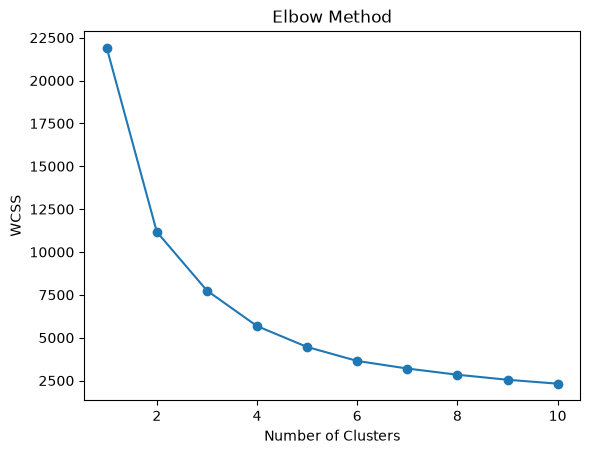

In [106]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

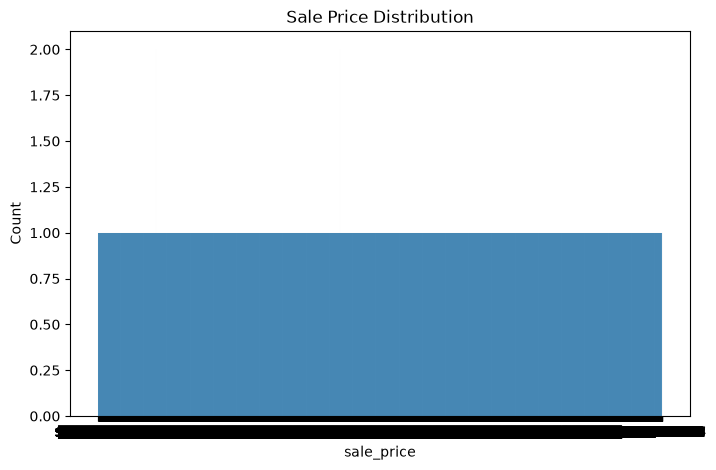

In [107]:

import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df["sale_price"], bins=30)
plt.title("Sale Price Distribution")
plt.show()

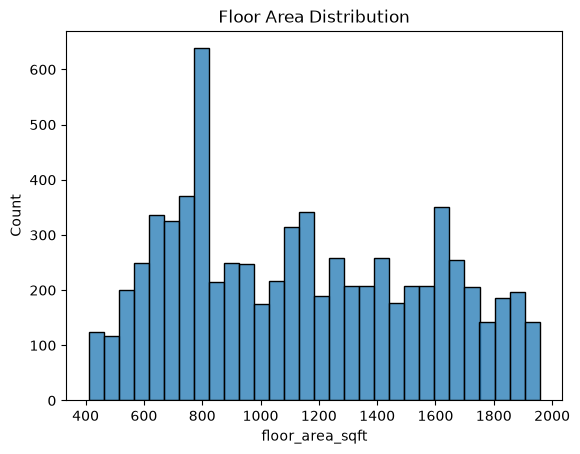

In [108]:
sns.histplot(df["floor_area_sqft"], bins=30)
plt.title("Floor Area Distribution")
plt.show()

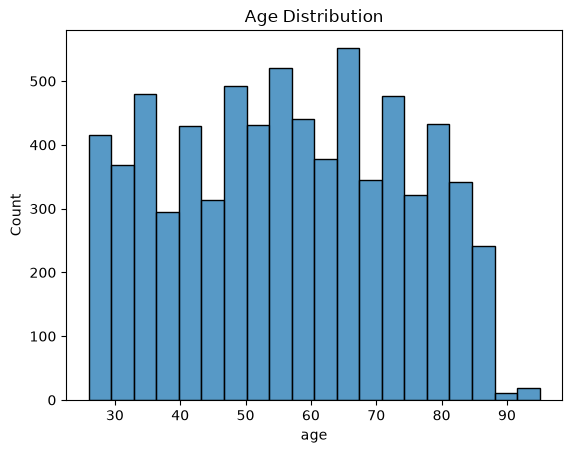

In [109]:
sns.histplot(df["age"], bins=20)
plt.title("Age Distribution")
plt.show()

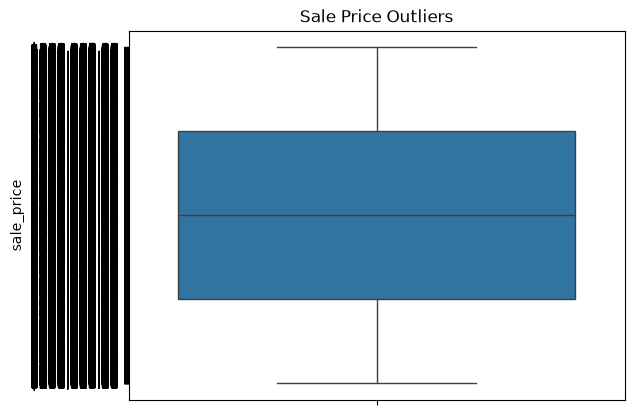

In [110]:
sns.boxplot(df["sale_price"])
plt.title("Sale Price Outliers")
plt.show()

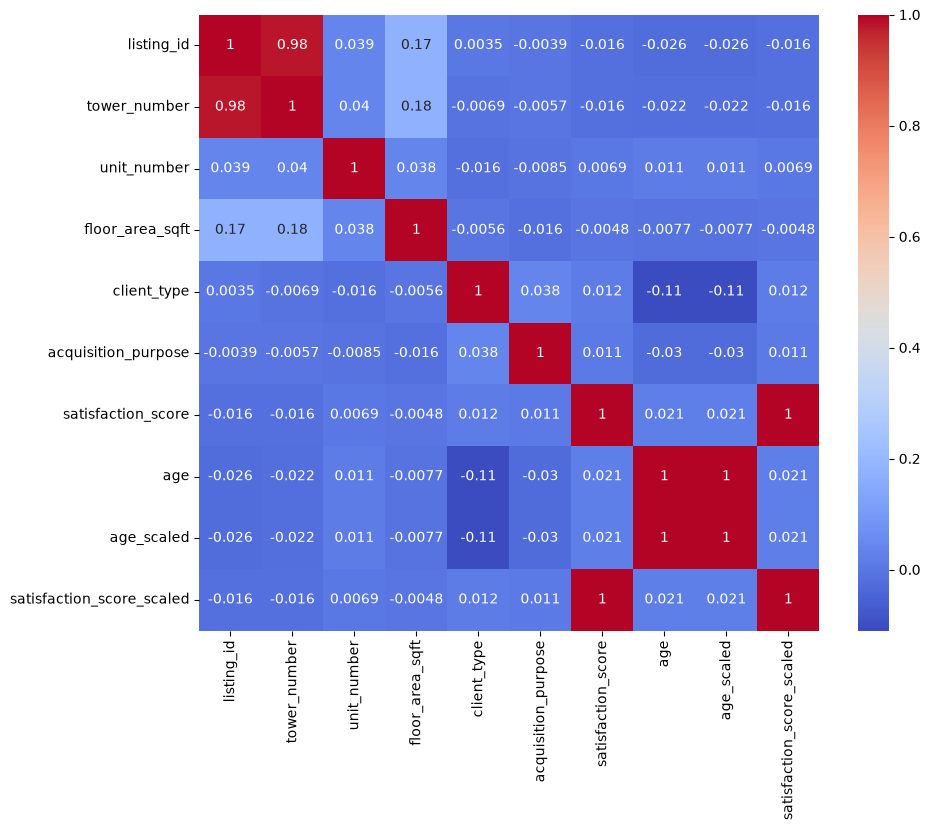

In [111]:
import numpy as np

numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.show()

In [112]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["KMeans_Cluster"] = kmeans.fit_predict(scaled_data)

print(df["KMeans_Cluster"].value_counts())

KMeans_Cluster
0    2347
1    1988
2    1721
3    1249
Name: count, dtype: int64


In [113]:
print(
    df["KMeans_Cluster"]
    .value_counts()
)

KMeans_Cluster
0    2347
1    1988
2    1721
3    1249
Name: count, dtype: int64


In [115]:
linkage_matrix = linkage(
    scaled_data,
    method="ward"
)

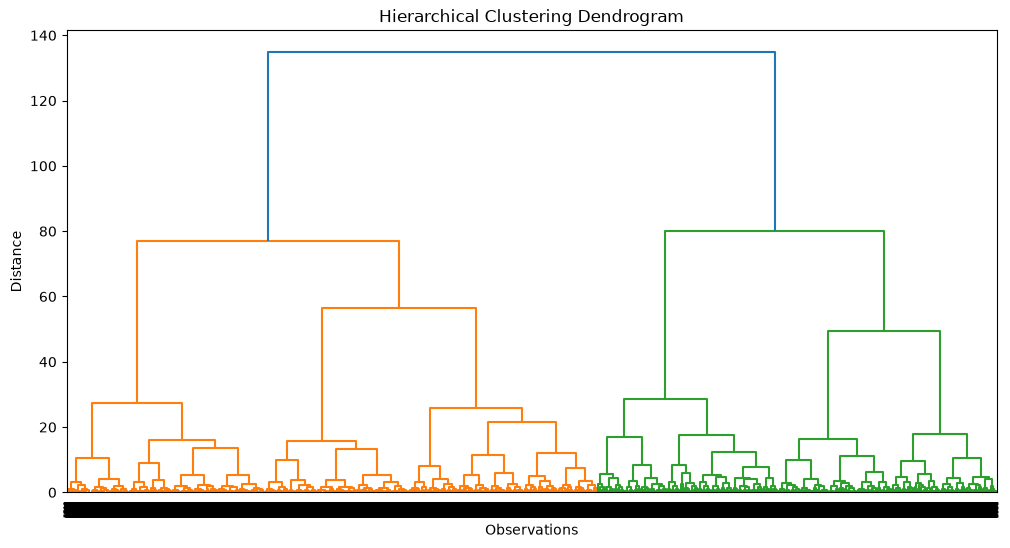

In [116]:
plt.figure(figsize=(12,6))

dendrogram(
    linkage_matrix
)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.xlabel("Observations")
plt.ylabel("Distance")

plt.show()

In [117]:
df["Hierarchical_Cluster"] = fcluster(
    linkage_matrix,
    4,
    criterion="maxclust"
)

In [118]:
print(
    df[
        [
            "KMeans_Cluster",
            "Hierarchical_Cluster"
        ]
    ].head()
)

   KMeans_Cluster  Hierarchical_Cluster
0               2                     2
1               2                     2
2               2                     2
3               2                     2
4               0                     1


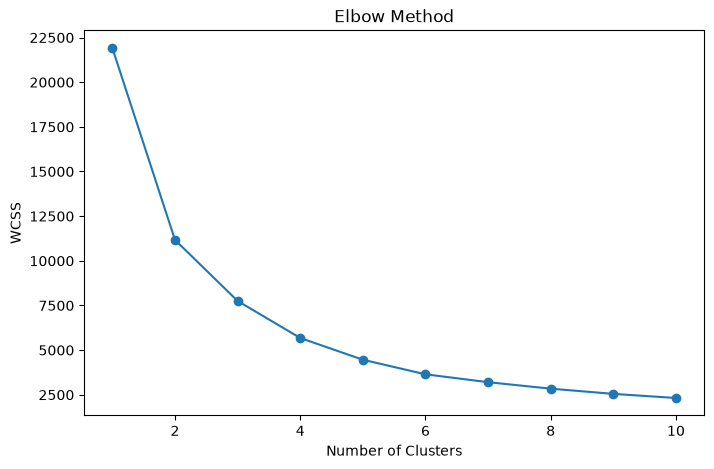

In [119]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [120]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [121]:
silhouette_scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        scaled_data
    )

    score = silhouette_score(
        scaled_data,
        labels
    )

    silhouette_scores.append(score)

    print(
        "Clusters:",
        k,
        "Silhouette Score:",
        round(score,4)
    )

Clusters: 2 Silhouette Score: 0.4214
Clusters: 3 Silhouette Score: 0.3999
Clusters: 4 Silhouette Score: 0.3866
Clusters: 5 Silhouette Score: 0.3897
Clusters: 6 Silhouette Score: 0.3837
Clusters: 7 Silhouette Score: 0.3662
Clusters: 8 Silhouette Score: 0.3689
Clusters: 9 Silhouette Score: 0.359
Clusters: 10 Silhouette Score: 0.3648


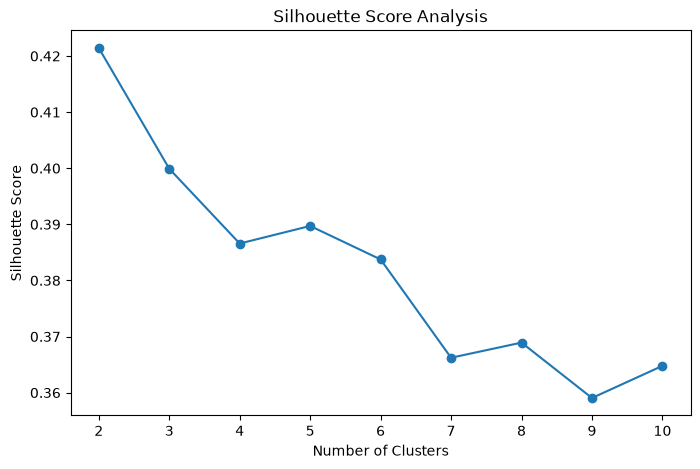

In [122]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker='o'
)

plt.title("Silhouette Score Analysis")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.show()

In [123]:
print(df["KMeans_Cluster"].value_counts())

KMeans_Cluster
0    2347
1    1988
2    1721
3    1249
Name: count, dtype: int64


In [124]:
pd.crosstab(
    df["KMeans_Cluster"],
    df["acquisition_purpose"]
)

acquisition_purpose,0,1
KMeans_Cluster,,
0,1621,726
1,1385,603
2,1169,552
3,883,366


In [125]:
print(
    pd.crosstab(
        df["KMeans_Cluster"],
        df["region"]
    )
)

region          Alberta  Arizona  Baja California  Bavaria  Berlin  \
KMeans_Cluster                                                       
0                    29      118                7       13      12   
1                    21      117                8       17      11   
2                    27       94                4        6       9   
3                    14       55                5        4       4   

region          British Columbia  Brittany  Brussels  California  \
KMeans_Cluster                                                     
0                             21        12        25         754   
1                             24        19         7         621   
2                             16        12         6         604   
3                             12        14        13         420   

region          Capital Region  ...  Texas  Utah  Victoria  Virginia  Wales  \
KMeans_Cluster                  ...                                           
0           

In [126]:
print(
    pd.crosstab(
        df["KMeans_Cluster"],
        df["loan_applied"]
    )
)

loan_applied      No  Yes
KMeans_Cluster           
0               1496  851
1               1264  724
2               1070  651
3                791  458


In [127]:
print(
    pd.crosstab(
        df["KMeans_Cluster"],
        df["gender"]
    )
)

gender             F     M
KMeans_Cluster            
0               1185  1162
1                942  1046
2                847   874
3                608   641


In [128]:
print(
    pd.crosstab(
        df["KMeans_Cluster"],
        df["client_type"]
    )
)

client_type        0    1
KMeans_Cluster           
0               2228  119
1               1878  110
2               1633   88
3               1185   64


In [129]:
print(df["date_of_birth"].sample(10))

1956   1970-01-27
202    1998-09-17
5829   1986-09-20
5881   1994-05-14
286    1971-05-29
548    1962-06-10
5946   1959-01-01
6977   1977-03-03
6676   1964-12-07
2690   1999-08-13
Name: date_of_birth, dtype: datetime64[ns]


In [130]:
df["date_of_birth"] = pd.to_datetime(
    df["date_of_birth"],
    errors="coerce"
)
print(df["date_of_birth"].isnull().sum())

0


In [131]:
df["age"] = (
    pd.Timestamp.today().year
    - df["date_of_birth"].dt.year
)
print(
    df.groupby("KMeans_Cluster")["age"]
    .mean()
)

KMeans_Cluster
0    56.518534
1    56.467807
2    56.699593
3    55.831865
Name: age, dtype: float64


In [132]:
df["sale_price"] = (
    df["sale_price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["sale_price"] = pd.to_numeric(df["sale_price"], errors="coerce")

In [133]:
# Make sure these columns are numeric
df["sale_price"] = pd.to_numeric(df["sale_price"], errors="coerce")
df["floor_area_sqft"] = pd.to_numeric(df["floor_area_sqft"], errors="coerce")
df["satisfaction_score"] = pd.to_numeric(df["satisfaction_score"], errors="coerce")

# Cluster profile
cluster_profile = df.groupby("KMeans_Cluster")[[
    "sale_price",
    "floor_area_sqft",
    "satisfaction_score"
]].mean()

print(cluster_profile)

                   sale_price  floor_area_sqft  satisfaction_score
KMeans_Cluster                                                    
0               245686.816625       819.411956            2.019599
1               472495.548566      1551.810694            3.989940
2               244011.663521       816.268321            4.517722
3               468261.632306      1539.733915            1.477982


In [138]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [135]:
%%writefile app.py
import streamlit as st

st.title("Buyer Segmentation Dashboard")

st.write("Real Estate Market Intelligence Project")

Overwriting app.py


In [142]:
%%writefile app.py
import streamlit as st
import pandas as pd

st.title("Machine Learning Based Buyer Segmentation")

clients = pd.read_csv("clients.csv")
properties = pd.read_csv("properties.csv")

st.header("Dataset Overview")

col1, col2 = st.columns(2)

with col1:
    st.metric("Total Clients", len(clients))

with col2:
    st.metric("Total Properties", len(properties))

st.header("Client Type Distribution")
st.bar_chart(clients["client_type"].value_counts())

st.header("Gender Distribution")
st.bar_chart(clients["gender"].value_counts())

st.header("Buyer Distribution by Region")
st.bar_chart(clients["region"].value_counts())

st.header("Acquisition Purpose")
st.bar_chart(clients["acquisition_purpose"].value_counts())

st.header("Sample Data")
st.dataframe(clients.head(20))

st.header("import matplotlib.pyplot as plt

st.header("Floor Area Distribution")

fig, ax = plt.subplots(figsize=(8,5))
df["floor_area_sqft"].hist(bins=20, ax=ax)

ax.set_xlabel("Floor Area (sq ft)")
ax.set_ylabel("Frequency")
ax.set_title("Histogram of Floor Area")

st.pyplot("Buyer Demographics and Channels")



Overwriting app.py
